In [13]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive')
#Once this is executed, you will see your drive appearing on the left hand side

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Define paths to the dataset
train_dir = '/content/drive/MyDrive/Fire_dataset/Train'  # Update with your actual path
test_dir = '/content/drive/MyDrive/Fire_dataset/Test'    # Update with your actual path

In [12]:
import os
print(len(os.listdir('/content/drive/MyDrive/Fire_dataset/Test/Fire')))
print(len(os.listdir('/content/drive/MyDrive/Fire_dataset/Test/Non-Fire')))
print(len(os.listdir('/content/drive/MyDrive/Fire_dataset/Train/Fire')))
print(len(os.listdir('/content/drive/MyDrive/Fire_dataset/Train/Non-Fire')))

1000
1000
3008
3000


In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (Fire vs. Non-Fire)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 4807 images belonging to 2 classes.
Found 1201 images belonging to 2 classes.


In [16]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [17]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # ✅ correct


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [ ]:
history = model.fit(train_data, epochs=30, validation_data=validation_data)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 187s 8s/step - accuracy: 0.5037 - loss: 0.8579 - val_accuracy: 0.5774 - val_loss: 0.6840
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.5585 - loss: 0.6714 - val_accuracy: 0.5714 - val_loss: 0.6701
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.6163 - loss: 0.6481 - val_accuracy: 0.5536 - val_loss: 0.7160
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.6919 - loss: 0.5770 - val_accuracy: 0.6071 - val_loss: 0.6335
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.7778 - loss: 0.4829 - val_accuracy: 0.6310 - val_loss: 0.6964
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.8385 - loss: 0.3719 - val_accuracy: 0.6369 - val_loss: 0.9542
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.9037 - loss: 0.2687 - val_accuracy: 0.6310 - val_loss: 0.8939
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.9185 - loss: 0.2167 - val_accuracy: 0.6

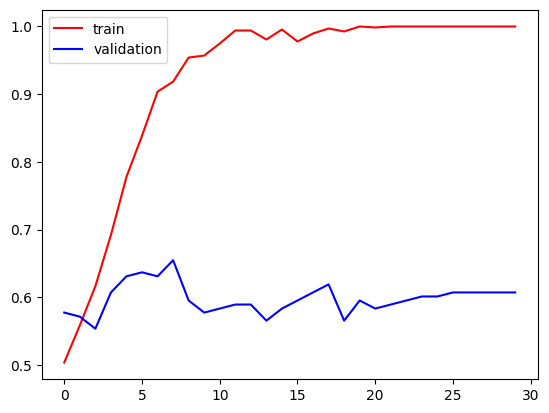

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

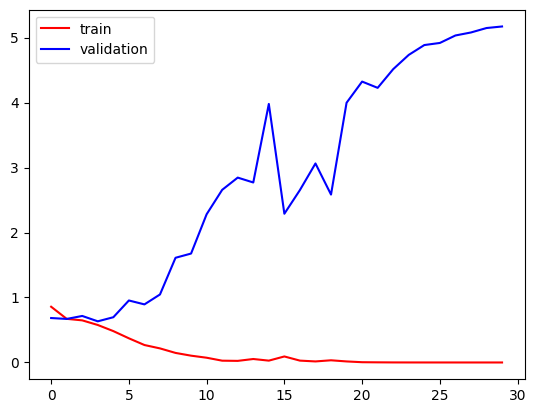

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [19]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    classes=['Fire', 'Non-Fire'],   # 🔥 FORCE only these two
    class_mode='binary'
)



Found 2000 images belonging to 2 classes.


In [20]:
#predict the test data
predictions = model.predict(test_data)


63/63 ━━━━━━━━━━━━━━━━━━━━ 349s 6s/step


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[500 500]
 [515 485]]
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.50      0.50      1000
           1       0.49      0.48      0.49      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



There is overfitting and hence applying Batchnormalisation and Dropout techniques to handle overfitting

In [ ]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(1,activation='sigmoid'))  #output layer

In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 457ms/step - accuracy: 0.5644 - loss: 5.3906 - val_accuracy: 0.4881 - val_loss: 5.0921
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.6741 - loss: 3.3913 - val_accuracy: 0.4881 - val_loss: 12.8296
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.6578 - loss: 3.5883 - val_accuracy: 0.4881 - val_loss: 6.2451
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.6726 - loss: 2.8721 - val_accuracy: 0.4881 - val_loss: 6.5818
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.6785 - loss: 1.8254 - val_accuracy: 0.4881 - val_loss: 22.8184
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.7022 - loss: 1.3033 - val_accuracy: 0.4881 - val_loss: 4.4335
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.7956 - loss: 1.0177 - val_accuracy: 0.4881 - val_loss: 5.8558
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.8311 - loss: 0.6189 - val_accuracy:

In [ ]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    classes=['cats', 'dogs'],   # 🔥 FORCE only these two
    class_mode='binary'
)


Found 134 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[54 20]
 [41 19]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.57      0.73      0.64        74
           1       0.49      0.32      0.38        60

    accuracy                           0.54       134
   macro avg       0.53      0.52      0.51       134
weighted avg       0.53      0.54      0.52       134



Using Pre-trained model - Resnet

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

In [ ]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = resnet_model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 749ms/step - accuracy: 0.5215 - loss: 2.9575 - val_accuracy: 0.5119 - val_loss: 1.8182
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.5822 - loss: 0.8194 - val_accuracy: 0.6071 - val_loss: 0.6386
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.6474 - loss: 0.6171 - val_accuracy: 0.6548 - val_loss: 0.6094
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.6356 - loss: 0.6215 - val_accuracy: 0.6726 - val_loss: 0.6259
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.6089 - loss: 0.6679 - val_accuracy: 0.6190 - val_loss: 0.6578
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 223ms/step - accuracy: 0.6356 - loss: 0.6703 - val_accuracy: 0.6548 - val_loss: 0.6361
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.6593 - loss: 0.6099 - val_accuracy: 0.6607 - val_loss: 0.6367
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.7007 - loss: 0.5672 - val_accuracy: 0

In [ ]:
predictions = resnet_model.predict(test_data)

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[ 7 67]
 [ 5 55]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.58      0.09      0.16        74
           1       0.45      0.92      0.60        60

    accuracy                           0.46       134
   macro avg       0.52      0.51      0.38       134
weighted avg       0.52      0.46      0.36       134



In [ ]:
from IPython.display import Image
Image(url='https://miro.medium.com/max/700/1*5BwZUqAqFFP5f3wKYQ6wJg.gif')

